In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
from statsmodels.tsa.seasonal import seasonal_decompose
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv(r"C:\Users\User\Desktop\Data Analysis\airline-performance\.env")
conn_str = f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT')}/{os.getenv('MYSQL_DATABASE')}"
engine = create_engine(conn_str)
images_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\images"

print("Connected, ready.")

Connected, ready.


In [4]:
chi_df = pd.read_sql("SELECT airline_code, delay_category FROM flights WHERE flight_id % 10 = 0", engine)
contingency = pd.crosstab(chi_df["airline_code"], chi_df["delay_category"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)

n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"Chi-square: {chi2:.1f}, p-value: {p:.2e}, dof: {dof}")
print(f"Cramér's V (0.1=small/0.3=medium/0.5=large): {cramers_v:.3f}")

Chi-square: 8393.2, p-value: 0.00e+00, dof: 65
Cramér's V (0.1=small/0.3=medium/0.5=large): 0.049


In [5]:
anova_df = pd.read_sql(
    "SELECT airline_code, arr_delay_minutes FROM flights WHERE flight_id % 10 = 0 AND cancelled=0 AND diverted=0 AND arr_delay_minutes IS NOT NULL",
    engine)
groups = [g["arr_delay_minutes"].values for _, g in anova_df.groupby("airline_code")]
f_stat, p_val = stats.f_oneway(*groups)
grand_mean = anova_df["arr_delay_minutes"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total = ((anova_df["arr_delay_minutes"] - grand_mean)**2).sum()
print(f"Airline ANOVA: F={f_stat:.1f}, p={p_val:.2e}, eta-squared (0.01=small/0.06=medium/0.14=large): {ss_between/ss_total:.4f}")

dow_df = pd.read_sql(
    """SELECT c.day_name, f.arr_delay_minutes FROM flights f JOIN calendar c ON f.flight_date=c.date_key
       WHERE f.flight_id % 10 = 0 AND f.cancelled=0 AND f.diverted=0 AND f.arr_delay_minutes IS NOT NULL""",
    engine)
dow_groups = [g["arr_delay_minutes"].values for _, g in dow_df.groupby("day_name")]
f_stat2, p_val2 = stats.f_oneway(*dow_groups)
print(f"Day-of-week ANOVA: F={f_stat2:.1f}, p={p_val2:.2e}")

Airline ANOVA: F=239.3, p=0.00e+00, eta-squared (0.01=small/0.06=medium/0.14=large): 0.0045
Day-of-week ANOVA: F=209.4, p=5.71e-268


In [6]:
ontime_df = pd.read_sql(
    """SELECT airline_code, SUM(CASE WHEN delay_category='On-time' THEN 1 ELSE 0 END) AS on_time_count, COUNT(*) AS total
       FROM flights GROUP BY airline_code""", engine)
ontime_df["on_time_pct"] = ontime_df["on_time_count"] / ontime_df["total"] * 100
ci_low, ci_high = proportion_confint(ontime_df["on_time_count"], ontime_df["total"], method="wilson")
ontime_df["ci_low"], ontime_df["ci_high"] = ci_low * 100, ci_high * 100
print(ontime_df[["airline_code","total","on_time_pct","ci_low","ci_high"]].sort_values("on_time_pct", ascending=False).round(2))

   airline_code    total  on_time_pct  ci_low  ci_high
6            HA    80084        81.95   81.68    82.21
3            DL  1026332        79.12   79.04    79.20
10           OO   839821        77.90   77.81    77.99
12           WN  1391885        77.76   77.69    77.82
11           UA   795271        77.65   77.56    77.75
8            NK   194515        77.25   77.06    77.43
7            MQ   299322        76.99   76.83    77.14
13           YX   346036        75.77   75.63    75.91
1            AS   245588        75.75   75.58    75.92
5            G4   130899        74.46   74.22    74.69
0            AA   973653        72.70   72.61    72.79
2            B6   231413        72.34   72.16    72.53
4            F9   198065        70.68   70.48    70.88
9            OH   248735        68.96   68.78    69.14


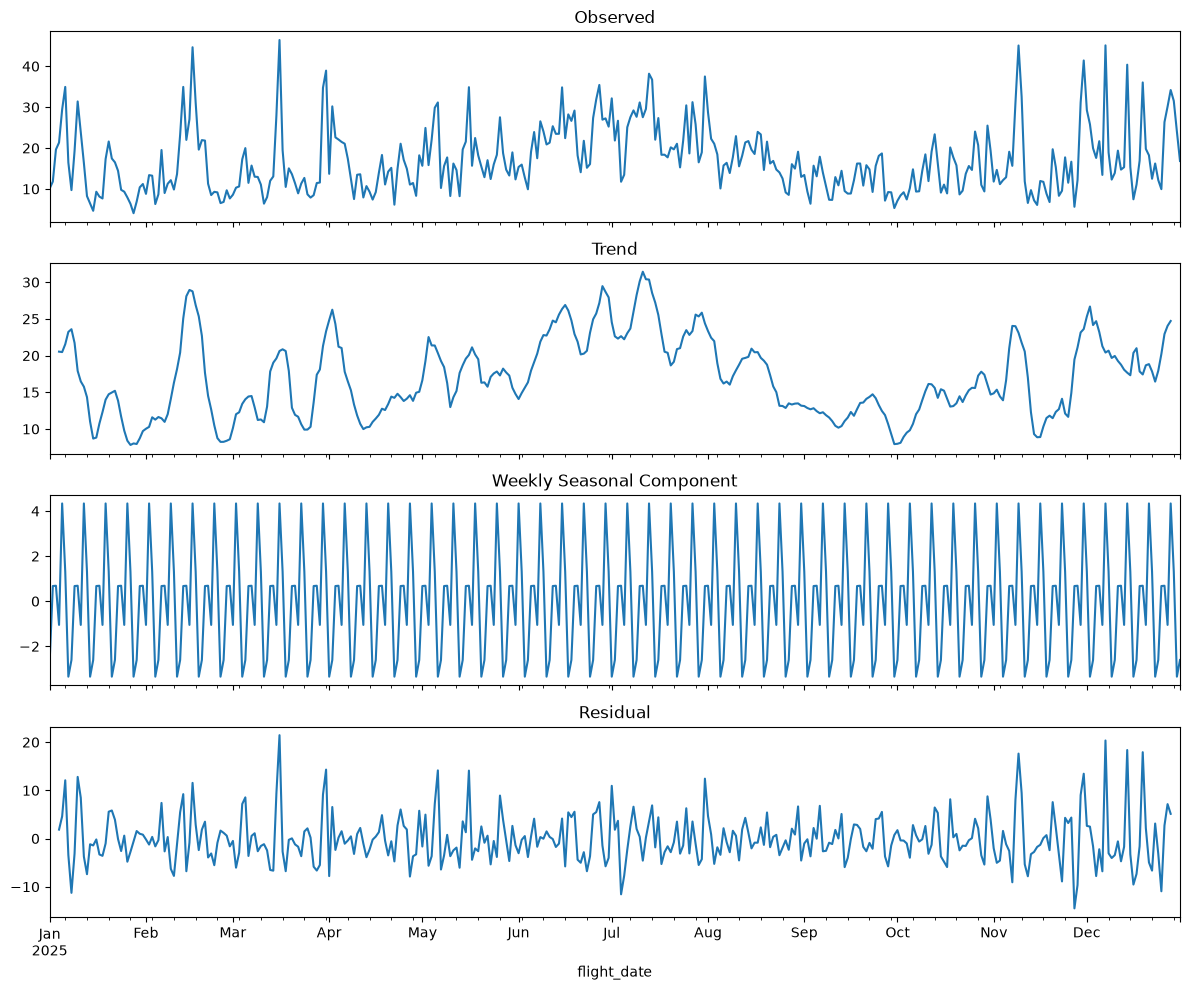


Avg delay by month (descriptive only):
flight_date
1     14.264749
2     15.754320
3     15.140584
4     14.531378
5     18.077417
6     22.674827
7     24.495987
8     17.442965
9     11.966914
10    14.008684
11    15.859322
12    20.853499
Name: avg_delay, dtype: float64


In [7]:
daily_df = pd.read_sql(
    "SELECT flight_date, AVG(arr_delay_minutes) AS avg_delay FROM flights WHERE cancelled=0 AND diverted=0 GROUP BY flight_date ORDER BY flight_date",
    engine)
daily_df["flight_date"] = pd.to_datetime(daily_df["flight_date"])
daily_df = daily_df.set_index("flight_date").asfreq("D")
daily_df["avg_delay"] = daily_df["avg_delay"].interpolate()

decomp = seasonal_decompose(daily_df["avg_delay"], model="additive", period=7)
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title="Observed"); decomp.trend.plot(ax=axes[1], title="Trend")
decomp.seasonal.plot(ax=axes[2], title="Weekly Seasonal Component"); decomp.resid.plot(ax=axes[3], title="Residual")
plt.tight_layout(); plt.savefig(images_dir + r"\seasonal_decomposition.png", dpi=150); plt.show()

monthly = daily_df.groupby(daily_df.index.month)["avg_delay"].mean()
print("\nAvg delay by month (descriptive only):")
print(monthly)

In [8]:
# Effect size for the day-of-week ANOVA (matching the airline calculation)
dow_grand_mean = dow_df["arr_delay_minutes"].mean()
dow_ss_between = sum(len(g) * (g["arr_delay_minutes"].mean() - dow_grand_mean)**2 for _, g in dow_df.groupby("day_name"))
dow_ss_total = ((dow_df["arr_delay_minutes"] - dow_grand_mean)**2).sum()
print(f"Day-of-week eta-squared: {dow_ss_between/dow_ss_total:.4f}")

# Which specific days are actually worst/best
print(dow_df.groupby("day_name")["arr_delay_minutes"].mean().sort_values(ascending=False))

# The residual spikes, single days that deviated hardest from trend + weekly pattern
top_residuals = decomp.resid.dropna().sort_values(ascending=False).head(5)
print("\nBiggest unexplained single-day spikes:")
print(top_residuals)

Day-of-week eta-squared: 0.0018
day_name
Sunday       21.439232
Monday       18.525524
Thursday     17.761972
Friday       17.600669
Saturday     16.024223
Wednesday    14.604404
Tuesday      13.907979
Name: arr_delay_minutes, dtype: float64

Biggest unexplained single-day spikes:
flight_date
2025-03-16    21.456952
2025-12-07    20.354819
2025-12-14    18.373242
2025-12-19    17.923892
2025-11-09    17.632286
Name: resid, dtype: float64


In [9]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill

load_dotenv(r"C:\Users\User\Desktop\Data Analysis\airline-performance\.env")
conn_str = f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT')}/{os.getenv('MYSQL_DATABASE')}"
engine = create_engine(conn_str)
excel_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\excel"

raw_query = """
SELECT
    f.flight_date, c.month, c.day_name, c.is_weekend, al.airline_name,
    COUNT(*) AS total_flights,
    SUM(CASE WHEN f.cancelled THEN 1 ELSE 0 END) AS cancelled_flights,
    SUM(CASE WHEN f.diverted THEN 1 ELSE 0 END) AS diverted_flights,
    SUM(CASE WHEN f.delay_category = 'On-time' THEN 1 ELSE 0 END) AS on_time_flights,
    ROUND(AVG(f.dep_delay_minutes), 1) AS avg_dep_delay,
    ROUND(AVG(f.arr_delay_minutes), 1) AS avg_arr_delay,
    ROUND(SUM(CASE WHEN f.delay_category = 'On-time' THEN 1 ELSE 0 END) / COUNT(*) * 100, 1) AS on_time_pct,
    ROUND(SUM(CASE WHEN f.cancelled THEN 1 ELSE 0 END) / COUNT(*) * 100, 2) AS cancellation_rate_pct
FROM flights f
JOIN calendar c ON f.flight_date = c.date_key
JOIN airlines al ON f.airline_code = al.airline_code
GROUP BY f.flight_date, c.month, c.day_name, c.is_weekend, al.airline_name
"""
raw_df = pd.read_sql(raw_query, engine)
print(f"Raw data rows: {len(raw_df):,}")

kpi_df = pd.read_sql("""
SELECT COUNT(*) AS total_flights,
    ROUND(SUM(CASE WHEN delay_category='On-time' THEN 1 ELSE 0 END)/COUNT(*)*100, 2) AS on_time_pct,
    ROUND(AVG(arr_delay_minutes), 2) AS avg_delay_min,
    ROUND(SUM(CASE WHEN cancelled THEN 1 ELSE 0 END)/COUNT(*)*100, 2) AS cancellation_rate_pct
FROM flights""", engine)

airline_df = pd.read_sql("""
SELECT al.airline_name, COUNT(*) AS total_flights,
    ROUND(SUM(CASE WHEN f.delay_category='On-time' THEN 1 ELSE 0 END)/COUNT(*)*100, 2) AS on_time_pct,
    ROUND(AVG(f.arr_delay_minutes), 2) AS avg_delay_min,
    ROUND(SUM(CASE WHEN f.cancelled THEN 1 ELSE 0 END)/COUNT(*)*100, 2) AS cancellation_rate_pct
FROM flights f JOIN airlines al ON f.airline_code = al.airline_code
GROUP BY al.airline_name ORDER BY on_time_pct DESC""", engine)

month_df = pd.read_sql("""
SELECT c.month, COUNT(*) AS total_flights,
    ROUND(AVG(f.arr_delay_minutes), 2) AS avg_delay_min,
    ROUND(SUM(CASE WHEN f.cancelled THEN 1 ELSE 0 END)/COUNT(*)*100, 2) AS cancellation_rate_pct
FROM flights f JOIN calendar c ON f.flight_date = c.date_key
GROUP BY c.month ORDER BY c.month""", engine)

output_path = excel_dir + r"\Airline_Performance_KPI_Workbook.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    kpi_df.to_excel(writer, sheet_name="KPI Summary", index=False)
    airline_df.to_excel(writer, sheet_name="By Airline", index=False)
    month_df.to_excel(writer, sheet_name="By Month", index=False)
    raw_df.to_excel(writer, sheet_name="Raw Data", index=False)

wb = load_workbook(output_path)
header_fill = PatternFill(start_color="1F4E5F", end_color="1F4E5F", fill_type="solid")
header_font = Font(color="FFFFFF", bold=True)
for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
    ws.freeze_panes = "A2"
    for col in ws.columns:
        max_len = max((len(str(c.value)) if c.value is not None else 0) for c in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 40)
wb.save(output_path)
print(f"Workbook saved: {output_path}")

Raw data rows: 5,110
Workbook saved: C:\Users\User\Desktop\Data Analysis\airline-performance\excel\Airline_Performance_KPI_Workbook.xlsx


In [10]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv(r"C:\Users\User\Desktop\Data Analysis\airline-performance\.env")
conn_str = f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT')}/{os.getenv('MYSQL_DATABASE')}"
engine = create_engine(conn_str)
excel_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\excel"
output_path = excel_dir + r"\Airline_Performance_KPI_Workbook.xlsx"

raw_query = """
SELECT
    f.flight_date, c.month, c.day_name, c.is_weekend, al.airline_name,
    COUNT(*) AS total_flights,
    SUM(CASE WHEN f.cancelled THEN 1 ELSE 0 END) AS cancelled_flights,
    SUM(CASE WHEN f.delay_category = 'On-time' THEN 1 ELSE 0 END) AS on_time_flights,
    SUM(CASE WHEN f.cancelled = 0 AND f.diverted = 0 THEN 1 ELSE 0 END) AS valid_flights_for_delay,
    SUM(f.arr_delay_minutes) AS total_arr_delay_minutes,
    ROUND(SUM(CASE WHEN f.cancelled THEN 1 ELSE 0 END) / COUNT(*) * 100, 2) AS cancellation_rate_pct
FROM flights f
JOIN calendar c ON f.flight_date = c.date_key
JOIN airlines al ON f.airline_code = al.airline_code
GROUP BY f.flight_date, c.month, c.day_name, c.is_weekend, al.airline_name
"""
raw_df = pd.read_sql(raw_query, engine)

with pd.ExcelWriter(output_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    raw_df.to_excel(writer, sheet_name="Raw Data", index=False)
print("Updated.")

Updated.


In [11]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv(r"C:\Users\User\Desktop\Data Analysis\airline-performance\.env")
conn_str = f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT')}/{os.getenv('MYSQL_DATABASE')}"
engine = create_engine(conn_str)
images_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\images"

airport_query = """
SELECT ap.airport_name, ap.city, ap.state, ap.latitude, ap.longitude,
    COUNT(*) AS total_flights, AVG(o.arr_delay_minutes) AS avg_arr_delay
FROM flights o JOIN airports ap ON o.origin_code = ap.airport_code
GROUP BY ap.airport_name, ap.city, ap.state, ap.latitude, ap.longitude
HAVING COUNT(*) >= 500
"""
airport_geo = pd.read_sql(airport_query, engine)
geometry = [Point(xy) for xy in zip(airport_geo["longitude"], airport_geo["latitude"])]
airport_gdf = gpd.GeoDataFrame(airport_geo, geometry=geometry, crs="EPSG:4326")
fig2 = px.scatter_geo(airport_gdf, lat=airport_gdf.geometry.y, lon=airport_gdf.geometry.x,
    size="total_flights", color="avg_arr_delay", color_continuous_scale="RdYlGn_r",
    hover_name="airport_name", scope="usa", title="Average Arrival Delay by Airport (500+ flights)")
fig2.write_image(images_dir + r"\airport_delay_map.png", width=1000, height=650, scale=2)

ts_df = pd.read_sql("SELECT flight_date, AVG(arr_delay_minutes) AS avg_delay FROM flights WHERE cancelled=0 AND diverted=0 GROUP BY flight_date ORDER BY flight_date", engine)
fig3 = go.Figure(go.Scatter(x=ts_df["flight_date"], y=ts_df["avg_delay"], mode="lines"))
fig3.update_layout(title="Average Arrival Delay by Day, 2025", xaxis_title="Date", yaxis_title="Minutes")
fig3.write_image(images_dir + r"\delay_time_series.png", width=1000, height=500, scale=2)
print("Saved both as static PNGs.")

Saved both as static PNGs.
